In [1]:
def plotter(file_gen,file_syn,xpsamp,A_V,Name,Spec_wave,norm_spec_flux,eff_temp,sur_g):
    import numpy as np
    import pandas as pd
    def near(A,value):
        import numpy as np
        idx = (np.abs(A-value)).argmin()
        return (idx)
    from SED_run_Gen import SED_fit,sed_file_gen
    import matplotlib.pyplot as plt
    from astropy.io import ascii
    from mpl_toolkits.axes_grid.inset_locator import inset_axes
    import extinction as ex

    plt.rcParams['figure.figsize'] = 15,10

    plt.rcParams['axes.linewidth'] = 2
    plt.rcParams['xtick.major.size'] = 25
    plt.rcParams['xtick.minor.size'] = 5
    plt.rcParams['ytick.major.size'] = 25
    plt.rcParams['ytick.minor.size'] = 5
    plt.rcParams['xtick.major.width'] = 2
    plt.rcParams['ytick.major.width'] = 2
    plt.rcParams['xtick.minor.width'] = 1
    plt.rcParams['ytick.minor.width'] = 1

    plt.rcParams['xtick.minor.visible'] = True
    plt.rcParams['ytick.minor.visible'] = True


    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['xtick.top'] = True
    plt.rcParams['ytick.right'] = True
    
    
    if type(xpsamp) == pd.core.frame.DataFrame:
        df1 = xpsamp
    if type(xpsamp) == str:
        df1 = pd.read_csv(xpsamp)
    wavelength = df1['wavelength']/1000
    flux = df1['flux']/10



    alambda_av = ex.extinction(wavelength,A_V)
    #print (alambda_av)
    #print type(alambda_av)
    alambda = A_V*alambda_av
    opacity = alambda/1.086
    #print (opacity)

    flux_intrinsic = flux*np.exp(opacity)
    flux_intrinsic = flux_intrinsic*1000

    fig = plt.figure(facecolor='white')

    A = flux_wavel_dict(file_gen)

    print(A)
    x = []
    y = []
    z = []
    for i in A:
            #print(A[i][0])
            #a = A[i][1]
            y.append(A[i][1])
            z.append(A[i][2])
            x.append(A[i][0])

    plt.errorbar(x,y,yerr=z,marker='v',ms=13, mfc='red',ls='none',label='Observed Photometric flux')

    A = flux_wavel_dict(file_syn)

    print(A)
    x = []
    y = []
    z = []
    for i in A:
            #print(A[i][0])
            #a = A[i][1]
            y.append(A[i][1])
            z.append(A[i][2])
            x.append(A[i][0])
    plt.plot(Spec_wave,norm_spec_flux,'k-',linewidth=1,alpha=0.4,label='BT-NextGen(AGSS2009)\nTeff = %s K, log g = %s'%(eff_temp,sur_g))
    #plt.legend(loc='best',prop={'size': 10,'weight':'bold'}, ncol=1)
    #plt.xscale('log')
    #plt.yscale('log')
    plt.errorbar(x,y,yerr=z,marker='o',ms=16, mfc='none',mec='k',mew=2.1,ls='none',label='Synthetic Photometric flux')
    #plt.errorbar(x[-1:],y[-1:],yerr=z[-1:],marker='o',ms=10, mfc='k',ls='none',label='IRAC Bands')

    #plt.plot(df1['wavelength']*10,df1['flux']*100,linewidth=2.5,color='g',label='BP/RP Spectra')
    
    
    plt.annotate("H$\\alpha$",(6500,7e-14),fontsize=18,fontweight='bold')
    plt.plot(df1['wavelength']*10,flux_intrinsic,linewidth=2.5,color='g',label='BP/RP Spectra')

    plt.tick_params(direction='in', which ="major",labelsize = 15,length=8, width=2, 
                    colors='k',grid_color='k', grid_alpha=1,bottom=True, top=True, left=True, right=True)
    plt.xticks(weight = 'bold')
    plt.yticks(weight = 'bold')
    
    #plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Wavelength ($\AA$)',fontsize=18,fontweight='bold')
    plt.ylabel('$\lambda F_\lambda$ $(erg/cm^2 /s)$',fontsize=18,fontweight='bold')


    plt.xlim(min(x)-500,max(x)+500)
    plt.ylim(min(y)-1.5*(min(y)/0.21e1),max(y)+(max(y)/0.21e1))
    plt.legend(prop={'size': 16,'weight':'bold'}, ncol=1)

    plt.title("%s"%Name,fontsize=18,fontweight='bold')
    #plt.plot(x,y)
    #plt.xticks([])
    #plt.yticks([])

    fig.set_size_inches(13.5, 7.5)
    fig.savefig('/home/arun/Desktop/OBA_DR3/fig/%s.pdf'%Name)
    
def sed_file_gen(Name, Av):
    from astroquery.vizier import Vizier
    from astroquery.mast import Catalogs
    import astropy.units as units
    import matplotlib.pyplot as plt
    import astropy.units as u
    import astropy.coordinates as coord
    import os
    import csv
    import numpy as np
    v = Vizier(columns=["*", "+_r"])
    Phot_Name = []
    Gaia_dat = ['Name','RA','DEC','Av','Dist','Gmag','e_Gmag','BPmag','e_BPmag','RPmag','e_RPmag']
    TWOMASS_dat = ['Jmag','e_Jmag','Hmag','e_Hmag','Ksmag','e_Ksmag']
    WISE_dat = ['W1mag','e_W1mag','W2mag','e_W2mag','W3mag','e_W3mag','W4mag','e_W4mag']
    SDSS_dat = ['umag','e_umag','gmag','e_gmag','rmag','e_rmag','imag','e_imag','zmag','e_zmag']
    B_V_dat = ['JsBmag','e_JsBmag','JsVmag','e_JsVmag']
    Galex_dat = ['gxfuvmag','e_gxfuvmag','gxnuvmag','e_gxnuvmag']
    Phot = []
    try:#
        Gaia = v.query_region(Name, radius="5s",catalog="I/350/gaiaedr3")
        Star_ID = Gaia[0][0]['Source']
        Bailer = v.query_region('Gaia EDR3 '+str(Star_ID), radius="2s",catalog="I/352/gedr3dis")
        print(len(Gaia[0]))
        Phot_Name.append(Gaia_dat)
        Phot_Name = np.reshape(Phot_Name, (11))
        A = [Name,Gaia[0][0]['RA_ICRS'],Gaia[0][0]['DE_ICRS'],Av,Bailer[0][0]['rgeo'],Gaia[0][0]['Gmag'],
             Gaia[0][0]['e_Gmag'],Gaia[0][0]['BPmag'],Gaia[0][0]['e_BPmag'],Gaia[0][0]['RPmag'],
             Gaia[0][0]['e_RPmag']]
        Phot.append(A)
        A = np.reshape(A, (11))
    except:
        IndexError
    try:#
        twomass = v.query_region(Name, radius="5s",catalog="II/246/out")
        print(len(twomass[0]))
        Phot_Name = np.append(Phot_Name,TWOMASS_dat)
        B = [twomass[0][0]["Jmag"],twomass[0][0]["e_Jmag"],twomass[0][0]["Hmag"],
             twomass[0][0]["e_Hmag"],twomass[0][0]["Kmag"],twomass[0][0]["e_Kmag"],]
        Phot = np.append(Phot,B)
    
    except:
        IndexError
    try:#
        wise = v.query_region(Name, radius="5s",catalog="II/328/allwise")
        print(len(wise[0]))
        Phot_Name = np.append(Phot_Name,WISE_dat)
        C = [wise[0][0]['W1mag'],wise[0][0]['e_W1mag'],wise[0][0]['W2mag'],wise[0][0]['e_W2mag'],
             wise[0][0]['W3mag'],wise[0][0]['e_W3mag'],wise[0][0]['W4mag'],wise[0][0]['e_W4mag']]
        Phot = np.append(Phot,C)
    except:
        IndexError


        
    file_name = "/home/arun/Desktop/SED/General_SED/SED_file/SED_%s.csv"%Name
    with open(file_name, 'a') as writeFile1:
        writer = csv.writer(writeFile1)
        np.savetxt(writeFile1,[Phot_Name], delimiter=',', fmt='%s')
        np.savetxt(writeFile1,[Phot], delimiter=',', fmt='%s')
        writeFile1.close()
    return(file_name)

def flux_wavel_dict(phot_filename):
    import pandas as pd
    import timeit
    import numpy as np
    import copy
    import matplotlib.pyplot as plt
    import os
    import csv
    import matplotlib.backends.backend_pdf
    import astropy
    from astropy import units as u
    from astropy.coordinates import SkyCoord
    from astropy.table import Table
    from scipy import interpolate
    from scipy.interpolate import interp1d 
    from astropy.io import ascii
    dict_of_wavelength_info={'Gmag': [23, 5822.39, 3228.75, 0.93444], 'BPmag': [27, 5035.75, 3552.01, 1.12978], 'RPmag': [31, 7619.96, 2554.95, 0.66304], 'gpsmag': [18, 4775.6, 3909.1, 1.2013], 'rpsmag': [23, 6129.5, 3151.4, 0.88592], 'ipsmag': [28, 7484.6, 2584.6, 0.67699], 'zpsmag': [33, 8657.8, 2273.1, 0.51994], 'ypsmag': [38, 9613.5, 2203.0, 0.44049], 'Jmag': [20, 12350, 1594, 0.28726], 'Hmag': [23, 16620, 1024, 0.17256], 'Ksmag': [26, 21590, 666.7, 0.11157], 'IRAC1mag': [74, 35075.1, 280.9, 0.04913], 'IRAC2mag': [76, 44365.8, 179.7, 0.03504], 'IRAC3mag': [78, 56281.0, 115.0, 0.0265], 'IRAC4mag': [80, 75891.6, 64.9, 0.0265], 'W1mag': [0, 33526.0, 309.5, 0.05296], 'W2mag': [0, 46028.0, 171.8, 0.03252], 'W3mag': [0, 115608.0, 31.7, 0.0265], 'W4mag': [0, 220883.0, 8.4, 0.0265],'MIPSmag': [0, 238433.07, 7.07, 0.0265], 'JsBmag': [0, 4378.1, 4023.8, 1.31758], 'JsVmag': [0, 5466.1, 3562.5, 0.99997], 'JsRmag': [0, 6695.6, 2814.9, 0.79224], 'JsImag': [0, 8565.1, 2282.8, 0.53235], 'Rcmag': [0, 6358.0, 3028.0, 0.84811], 'Icmag': [0, 7829.2, 2458.3, 0.63086], 'umag': [0, 3594.9, 1568.5, 1.55723], 'gmag': [0, 4640.4, 3965.9, 1.24072], 'rmag': [0, 6122.3, 3162.0, 0.88711], 'imag': [0, 7439.5, 2602.0, 0.68303], 'zmag': [0, 8897.7, 2244.7, 0.48782], 'upmag': [0, 3542.2, 1469.5, 1.57151], 'gpmag': [0, 4724.6, 3921.0, 1.21617], 'rpmag': [0, 6202.6, 3112.9, 0.87382], 'ipmag': [0, 7673.0, 2502.6, 0.65177], 'zpmag': [0, 10506.5, 1821.0, 0.39009], 'gxfuvmag': [0, 1549.0, 520.7, 2.60956],'JsUmag': [0, 3570.6, 1564.2, 1.4258], 'gxnuvmag': [0, 2304.7, 788.5, 2.79148], 'VistaJmag': [0, 12481.0, 1550.7, 0.28276], 'VistaHmag': [0, 16348.2, 1027.3, 0.17979], 'VistaKmag': [0, 21435.5, 669.6, 0.11460],'N_Ksmag': [0, 21240.60, 677.43, 0.1170],'Lpmag': [0, 37301.72, 248.30, 0.04621],'IPHAS_Hamag':[0,6568.2,2609.8,0.81]}
    '''
    dict_of_wavelength_info={'Gmag': [23, 5836.3, 2835.1, 0.948], 'BPmag': [27, 5020.9, 3393.3, 1.08017], 'RPmag': [31, 7588.8, 2485.1, 0.71945], 'gpsmag': [18, 4775.6, 3909.1, 1.12435], 'rpsmag': [23, 6129.5, 3151.4, 0.908], 'ipsmag': [28, 7484.6, 2584.6, 0.7318], 'zpsmag': [33, 8657.8, 2273.1, 0.59272], 'ypsmag': [38, 9603.1, 2206.0, 0.51298], 'Jmag': [20, 12350, 1594, 0.33454], 'Hmag': [23, 16620, 1024, 0.20096], 'Ksmag': [26, 21590, 666.7, 0.12993], 'IRAC1mag': [74, 35075.1, 280.9, 0.05721], 'IRAC2mag': [76, 44365.8, 179.7, 0.04081], 'IRAC3mag': [78, 56281.0, 115.0, 0.03086], 'IRAC4mag': [80, 75891.6, 64.9, 0.03086], 'W1mag': [0, 33526.0, 309.5, 0.06168], 'W2mag': [0, 46028.0, 171.8, 0.03787], 'W3mag': [0, 115608.0, 31.7, 0.03086], 'W4mag': [0, 220883.0, 8.4, 0.03086], 'JsBmag': [0, 4378.1, 4023.8, 1.1958],'JsUmag': [0, 3570.6, 1564.2, 1.2858], 'JsVmag': [0, 5466.1, 3562.5, 0.99998], 'JsRmag': [0, 6695.6, 2814.9, 0.83078], 'JsImag': [0, 8565.1, 2282.8, 0.60371], 'Rcmag': [0, 6358.0, 3028.0, 0.87683], 'Icmag': [0, 7829.2, 2458.3, 0.69095], 'umag': [0, 3594.9, 1568.5, 1.32448], 'gmag': [0, 4640.4, 3965.9, 1.1487], 'rmag': [0, 6122.3, 3162.0, 0.90899], 'imag': [0, 7439.5, 2602.0, 0.73715], 'zmag': [0, 8897.7, 2244.7, 0.56428], 'upmag': [0, 3542.2, 1469.5, 1.32692], 'gpmag': [0, 4724.6, 3921.0, 1.13354], 'rpmag': [0, 6202.6, 3112.9, 0.89803], 'ipmag': [0, 7673.0, 2502.6, 0.70947], 'zpmag': [0, 10506.5, 1821.0, 0.45429], 'gxnuvmag': [0, 1549.0, 520.7, 1.48909], 'gxfuvmag': [0, 2304.7, 788.5, 1.79283]}

    '''


    Vega_mag_optbands=['Gmag','BPmag','RPmag','Icmag','Rcmag','JsVmag','JsBmag','JsUmag','JsRmag','JsImag','Jmag','Hmag','Ksmag','IRAC1mag','IRAC2mag','IRAC3mag','IRAC4mag','W1mag','MIPSmag','W2mag','W3mag','W4mag','VistaJmag','VistaHmag','VistaKmag','N_Ksmag','Lpmag','IPHAS_Hamag']
    AB_mag_optbands=['gpsmag', 'rpsmag', 'ipsmag', 'zpsmag', 'ypsmag','gpmag','rpmag','ipmag','gxnuvmag','gxfuvmag','umag','gmag','rmag','imag','zmag']#should add more optical bands respectively
    wv_info=copy.deepcopy(dict_of_wavelength_info)
    list_all_wavelengths_mstr=[p[1] for p in list(wv_info.values())] 
    zero_magnitude_flux_mstr=[p[2] for p in list(wv_info.values())]
    objct_flux_data=dict() 
    all_obj_wavelengths=dict()                          # Dictionary containing all the wavelength bands (wavelength values) that are available for the stars showing IR excess.
    all_objct_flux_data_list=dict()
    all_obj_extinction = dict()
    
    if type(phot_filename) == pd.core.frame.DataFrame:
        star_phot_data = phot_filename
    if type(phot_filename) == str:
        star_phot_data = pd.read_csv(phot_filename,na_values=['-','999','-999'])

    for index,row in star_phot_data.iterrows():
        AV = np.float(row['Av'])
        Star_name = row['Name']
        Distance_pc = np.float(row['Dist'])
    #print(index)    
    opt_bands=[]
    bands=[]
    lis_opt_wvls=[]## Only if the object has data in all 2MASS bands plus IRAC 1&2, is the object considered for furter analysis
        #print(row[['Jmag','Hmag','Ksmag','IRAC1mag','IRAC2mag']].notna())
    obj_bands=[]################################
    list_all_wavelengths=[]
    dict_obj_mags = dict()
    flux_wvlngth=dict()
    flx_err=dict()
    err_cnt=0
    dict_obj_mags_wo_corctn = dict()
    dict_obj_mags_err = dict()
    for bnd_nm in dict_of_wavelength_info:
        all_obj_extinction[bnd_nm] = dict_of_wavelength_info[bnd_nm][3]*AV
    for bnd_nm in dict_of_wavelength_info:
                if (bnd_nm in star_phot_data.columns) and (row[[bnd_nm]].notna().sum()) == 1:
                    opt_bands.append(bnd_nm)
                    dict_obj_mags[bnd_nm]=float(row[bnd_nm])-all_obj_extinction[bnd_nm]
                    dict_obj_mags_wo_corctn[bnd_nm]=float(row[bnd_nm])
                    dict_obj_mags_err[bnd_nm]=float(row['e_'+bnd_nm])
                    lis_opt_wvls.append(wv_info[bnd_nm][1])
    bands=opt_bands+bands
    list_all_wavelengths=lis_opt_wvls+list_all_wavelengths
    list_opt_flx=[]
    list_opt_flx_err=[]
    for bnd_nm in opt_bands:
        if bnd_nm in Vega_mag_optbands:
            #print('sdfgds')
            mag_wvlngth=dict_obj_mags[bnd_nm]
            flux_wvlngth[bnd_nm]=(2.99792458e-05*(wv_info[bnd_nm][2]*10**(-mag_wvlngth/2.5)))/(wv_info[bnd_nm][1]**2)# Converting magnitude to flux in Jansky -> Converting Janksy to erg/cm2/s/A (formula from "http://www.stsci.edu/~strolger/docs/UNITS.txt") -> Finally multiplying with wvelength to get lambda*F_lambda in erg/cm2/s.
            list_opt_flx.append(flux_wvlngth[bnd_nm])
            mg_err=mag_wvlngth+float(row['e_'+bnd_nm])
            if float(row['e_'+bnd_nm])>90:
                mg_err=mag_wvlngth
            err_corctd_flx=(2.99792458e-05*(wv_info[bnd_nm][2]*10**(-mg_err/2.5)))/(wv_info[bnd_nm][1]**2)
            flx_err[bnd_nm]=flux_wvlngth[bnd_nm]-err_corctd_flx
            list_opt_flx_err.append(flx_err[bnd_nm])
        if bnd_nm in AB_mag_optbands:
            mag_wvlngth=dict_obj_mags[bnd_nm]
            flux_wvlngth[bnd_nm]=(2.99792458e-05*(3631*10**(-mag_wvlngth/2.5)))/(wv_info[bnd_nm][1]**2)           # Converting magnitude to flux in Jansky -> Converting Janksy to erg/cm2/s/A (formula from "http://www.stsci.edu/~strolger/docs/UNITS.txt") -> Finally multiplying with wvelength to get lambda*F_lambda in erg/cm2/s.
            list_opt_flx.append(flux_wvlngth[bnd_nm])
            mg_err=mag_wvlngth+float(row['e_'+bnd_nm])
            if float(row['e_'+bnd_nm])>90:
                mg_err=mag_wvlngth
            err_corctd_flx=(2.99792458e-05*(3631*10**(-mg_err/2.5)))/(wv_info[bnd_nm][1]**2)
            flx_err[bnd_nm]=flux_wvlngth[bnd_nm]-err_corctd_flx
            list_opt_flx_err.append(flx_err[bnd_nm])
                                                    
        objct_flux_data[index]=flux_wvlngth
        obj_nor_band_flux=objct_flux_data[index][opt_bands[0]]
    #print(flux_wvlngth,flx_err)
    a=[]
    b=[]
    for bnd_nm in bands:
        a.append(flux_wvlngth[bnd_nm])
        b.append(dict_of_wavelength_info[bnd_nm][1])
    final_dic = dict()
    final_dic1 = dict()
    final_dic2 = dict()
    for bnd_nm in flux_wvlngth:
        final_dic[bnd_nm]=flux_wvlngth[bnd_nm]
        final_dic1[bnd_nm] = dict_of_wavelength_info[bnd_nm][1]
        final_dic2[bnd_nm] = flx_err[bnd_nm]

    from itertools import chain
    from collections import defaultdict
    FINAL_DIC = defaultdict(list)
    for d in (final_dic1, final_dic, final_dic2): # you can list as many input dicts as you want here
        for key, value in d.items():
            FINAL_DIC[key].append(value)
    FINAL_DIC = dict(sorted(FINAL_DIC.items(), key=lambda k_v: k_v[1][0]))
    return(FINAL_DIC)

def near(A,value):
    import numpy as np
    idx = (np.abs(A-value)).argmin()
    return (idx)
def file_maker1(first_spectra_geom,geom_sampling):
    import pandas as pd
    wave = list(geom_sampling)
    flux = list(first_spectra_geom['flux'][0])
    flux_error = list(first_spectra_geom['flux_error'][0])
    d = {'wavelength': wave, 'flux': flux,'flux_error':flux_error }
    data_frame = pd.DataFrame(data=d)
    return (data_frame)

def fitter(FINAL_DIC,phot_filename):
    import pandas as pd
    import timeit
    import numpy as np
    import copy
    import matplotlib.pyplot as plt
    import os
    import csv
    import matplotlib.backends.backend_pdf
    import astropy
    from astropy import units as u
    from astropy.coordinates import SkyCoord
    from astropy.table import Table
    from scipy import interpolate
    from scipy.interpolate import interp1d 
    from astropy.io import ascii
    x = []
    y = []
    z = []
    if type(phot_filename) == pd.core.frame.DataFrame:
        star_phot_data = phot_filename
    if type(phot_filename) == str:
        star_phot_data = pd.read_csv(phot_filename,na_values=['-','999','-999'])
    for index,row in star_phot_data.iterrows():
        AV = np.float(row['Av'])
        Star_name = row['Name']
        Distance_pc = np.float(row['Dist'])
    for i in FINAL_DIC:
        #print(A[i][0])
        #a = A[i][1]
        x.append(FINAL_DIC[i][0])
        y.append(FINAL_DIC[i][1])
        z.append(FINAL_DIC[i][2])
    sed_fitting_bands = []
    for bnd_nm in FINAL_DIC:
        sed_fitting_bands.append(bnd_nm)
    print(sed_fitting_bands)

    filename_count = 0
    Temp_filename_dict = dict()
    least_sq_theo_sed=dict()

    path_to_theo_phot = "/home/arun/Desktop/SED/General_SED/LOG_4_5/bt-nextgen-agss2009_phot_1647494142.2956"
    for filename in os.listdir(path_to_theo_phot):
        filename_count+=1 
        indv_wvl_lambda_Flambda=dict()
        Temp_filename_dict[filename_count]=filename
        data = ascii.read(path_to_theo_phot+"/"+filename)
        A_wave = data.columns[1]
        B_flux = data.columns[2]
        Band_norm = 'JsVmag'
        wavel_n1 = FINAL_DIC[Band_norm][0]
        flux_n1 = FINAL_DIC[Band_norm][1]
        index_fit = near(A_wave,wavel_n1)
        norm_phot_flux = (B_flux/B_flux[index_fit])*flux_n1
        least_sq = []
        for chi_bnd in sed_fitting_bands:
            index_fit = near(A_wave,FINAL_DIC[chi_bnd][0])
            nor_temp_band_lambda_Flambda = norm_phot_flux[index_fit]
            obj_lambda_Flambda=FINAL_DIC[chi_bnd][1]# Object lambda_Flambda at that wavelength.
            obj_flx_err=FINAL_DIC[chi_bnd][2]# observed flux error in that band
            if obj_flx_err==0: # If there is not error then a high error value of 1 is taken.
                obj_flx_err=1
            x2=((obj_lambda_Flambda-nor_temp_band_lambda_Flambda)**2/nor_temp_band_lambda_Flambda)                                                         # Chi-squared or least sqaured formula using the theoretical and observed lambda_Flambda.
            eff_temp_1=float(filename[23:26])*100# The effective temperature of the best fit spectra
            sur_g_1=float(filename[27:30])
            least_sq.append(x2)

            total_x2=(1/(len(sed_fitting_bands)-1))*sum(least_sq)

        least_sq_theo_sed[filename]=sum(least_sq)
        #print(eff_temp_1,sur_g_1,sum(least_sq))
    #print(least_sq_theo_sed)
    spec_phot_filename=min(least_sq_theo_sed, key=least_sq_theo_sed.get)
    #print(spec_phot_filename)
    eff_temp=float(spec_phot_filename[23:26])*100# The effective temperature of the best fit spectra
    sur_g=float(spec_phot_filename[27:30])
    #print(eff_temp,sur_g)

    path_to_theo_spectra = "/home/arun/Desktop/SED/General_SED/LOG_4_5/bt-nextgen-agss2009"

    for spec_filename in os.listdir(path_to_theo_spectra):
        if spec_filename[3:6] == spec_phot_filename[23:26] and spec_filename[7:10] == spec_phot_filename[27:30]:
            spectra_fit_filename=spec_filename
    data_spectra_fit_filename = ascii.read(path_to_theo_spectra+"/"+spectra_fit_filename)
#print(spectra_fit_filename)
    data_PHOT = ascii.read(path_to_theo_phot+"/"+spec_phot_filename)

    Spec_wave = data_spectra_fit_filename.columns[0]
    Spec_flux = data_spectra_fit_filename.columns[1]
    Spec_index_fit = near(Spec_wave,wavel_n1)
    norm_spec_flux = (Spec_flux/Spec_flux[Spec_index_fit])*flux_n1
    A_wave = data_PHOT.columns[1]
    B_flux = data_PHOT.columns[2]
    index_fit = near(A_wave,wavel_n1)
    Md = flux_n1/B_flux[index_fit]
    norm_phot_flux = (B_flux*Md)
    #Radius = np.sqrt(Md*Distance_pc**2)*4.435e+7
    print("Star_name = ",Star_name,"Teff = ",eff_temp,"log g = ",sur_g)#,"Radius = ",Radius)
    #result = [Star_name,eff_temp,sur_g,Radius]
    wvx = []
    wvy = []
    for ss in FINAL_DIC:
        ind = near(A_wave,FINAL_DIC[ss][0])
        wvx.append(A_wave[ind])
        wvy.append(norm_phot_flux[ind])
    #plt.errorbar(x,y,yerr=z,marker='o',ms=10, mfc='red',ls='none',label='%s'%Star_name)
    #plt.scatter(wvx,wvy,color='b',s=40,label='Model_photometry')
    #plt.plot(Spec_wave,norm_spec_flux,'k-',linewidth=1,alpha=0.4,label='BT-NextGen(AGSS2009)\nTeff = %s K, log g = %s'%(str(eff_temp)[:-2],sur_g))
    #plt.legend(loc='best',prop={'size': 10,'weight':'bold'}, ncol=1)
    #plt.xscale('log')
    #plt.yscale('log')
    #plt.xlabel('Wavelength ($\AA$)',fontsize=18,fontweight='bold')
    #plt.ylabel('$F_\lambda$ $(erg/cm^2 /s/\AA)$',fontsize=18,fontweight='bold')
    #plt.xlim(min(x)-500,max(x)+5000)
    #plt.ylim(min(wvy)-(min(wvy)/0.21e1),max(wvy)+(max(wvy)/0.21e1))
    #params = {'mathtext.default': 'regular' }          
    #plt.rcParams.update(params)
    #plt.tick_params(direction='in', which ="major",labelsize = 15,length=8, width=2,colors='k',grid_color='k', grid_alpha=1,bottom=True, top=True, left=True, right=True)
    #plt.xticks(weight = 'bold')
    #plt.yticks(weight = 'bold')
    #plt.legend(prop={'size': 12,'weight':'bold'}, ncol=1)
    #fig =plt.gcf()
    #fig.set_size_inches(13.5, 8.5)
    return(Spec_wave,norm_spec_flux,str(eff_temp)[:-2],sur_g)



In [2]:

from gaiaxpy import convert
import os, glob
import matplotlib.pyplot as plt
import pandas as pd
from gaiaxpy import generate, PhotometricSystem
from gaiaxpy import plot_spectra,calibrate
import numpy as np

data = pd.read_csv("/home/arun/Desktop/OBA_DR3/final_OBA_DR3_complilation-result_all_allgaia.csv", low_memory=False)

synth_dic = {'Jkc_mag_U':'JsUmag','Jkc_mag_B':'JsBmag','Jkc_mag_V':'JsVmag','Jkc_mag_R':'JsRmag',
             'Jkc_mag_I':'JsImag','Sdss_mag_u':'umag','Sdss_mag_g':'gmag','Sdss_mag_r':'rmag',
             'Sdss_mag_i':'imag','Sdss_mag_z':'zmag','Panstarrs1_mag_gp':'gpsmag','Panstarrs1_mag_rp':'rpsmag',
             'Panstarrs1_mag_ip':'ipsmag','Panstarrs1_mag_zp':'zpsmag','Panstarrs1_mag_yp':'ypsmag',
             'GaiaDr3Vega_mag_G':'Gmag','GaiaDr3Vega_mag_BP':'BPmag','GaiaDr3Vega_mag_RP':'RPmag',
             'Iphas_mag_Ha':'IPHAS_Hamag'}

result = pd.DataFrame([])
xp = 'XP_CONTINUOUS-Gaia DR3 3152719334880801920.fits'
dat = '/home/arun/Desktop/OBA_DR3/xp_continuous_fits/'+xp
phot_system = [PhotometricSystem.JKC,PhotometricSystem.SDSS,PhotometricSystem.IPHAS,PhotometricSystem.Gaia_DR3_Vega]
synthetic_photometry = generate(dat, photometric_system=phot_system)

dataa = data[data['DR3Name'] == str(xp.split('-')[-1].split('.')[0])]
synthetic_photometry1 = pd.merge(dataa, synthetic_photometry)    #print(cont_spec.split('-')[-1].split('.')[0], synthetic_photometry.Iphas_mag_Ha.values)
result = pd.concat([result,synthetic_photometry1], ignore_index=True)
new_table = pd.DataFrame([])
a = "Gaia DR3 "+str(synthetic_photometry['source_id'].values[0])
new_table['Name'] = synthetic_photometry['source_id']
new_table['Name'] = "Gaia DR3 "+str(new_table['Name'].values[0])
new_table['Av'] = 0.1
new_table['Dist'] = 0.
A_V = new_table['Av'][0]
print(new_table)
for col in synthetic_photometry.columns:
    for bnd_nm in synth_dic:
        if col == bnd_nm:
            new_table[synth_dic[bnd_nm]] = synthetic_photometry[col].values[0]
            error = "e_"+synth_dic[bnd_nm]
            new_table[error]=0.1
            print(synthetic_photometry[col].values[0])
synth = "sample.csv"
new_table.to_csv(synth)

file_gen = sed_file_gen(dataa['DR3Name'].values[0], A_V)
#converted_spectra, sampling = convert(dat)
#xpsamp = "/home/arun/Desktop/OBA_DR3/xp_sampled/XP_SAMPLED-"+dataa['DR3Name'].values[0]+'.csv'

first_spectra_geom, geom_sampling = calibrate(dat, sampling=np.geomspace(336,1020, 342))
#output_path='/home/arun/Desktop/PHD/IL_Cep/DR3_ANALYSIS/sampled_generated', output_file="%s"%f[:-4])
#plot_spectra(first_spectra_geom, sampling=geom_sampling, legend=False)



xpsamp = file_maker1(first_spectra_geom,geom_sampling)

#A,B = SED_fit('./sed_files/SED_{}.csv'.format(dataa['DR3Name'].values[0]), xpsamp)
#plt.scatter(xpsamp['wavelength'], xpsamp['flux'])
Spec_wave,norm_spec_flux,eff_temp,sur_g = fitter(flux_wavel_dict(new_table),new_table)
plotter(file_gen,new_table,xpsamp,A_V,dataa['DR3Name'].values[0],Spec_wave,norm_spec_flux,eff_temp,sur_g)


FileNotFoundError: [Errno 2] No such file or directory: '/home/arun/Desktop/OBA_DR3/final_OBA_DR3_complilation-result_all_allgaia.csv'

In [ ]:
import os
path_to_theo_spectra = '/home/arun/Desktop/OBA_DR3/xp_continuous_fits/'
for spec_filename in os.listdir(path_to_theo_spectra):
    data = pd.read_csv("/home/arun/Desktop/OBA_DR3/final_OBA_DR3_complilation-result_all_allgaia.csv", low_memory=False)

    synth_dic = {'Jkc_mag_U':'JsUmag','Jkc_mag_B':'JsBmag','Jkc_mag_V':'JsVmag','Jkc_mag_R':'JsRmag',
                 'Jkc_mag_I':'JsImag','Sdss_mag_u':'umag','Sdss_mag_g':'gmag','Sdss_mag_r':'rmag',
                 'Sdss_mag_i':'imag','Sdss_mag_z':'zmag','Panstarrs1_mag_gp':'gpsmag','Panstarrs1_mag_rp':'rpsmag',
                 'Panstarrs1_mag_ip':'ipsmag','Panstarrs1_mag_zp':'zpsmag','Panstarrs1_mag_yp':'ypsmag',
                 'GaiaDr3Vega_mag_G':'Gmag','GaiaDr3Vega_mag_BP':'BPmag','GaiaDr3Vega_mag_RP':'RPmag',
                 'Iphas_mag_Ha':'IPHAS_Hamag'}

    result = pd.DataFrame([])
    xp = spec_filename
    dat = '/home/arun/Desktop/OBA_DR3/xp_continuous_fits/'+xp
    phot_system = [PhotometricSystem.JKC,PhotometricSystem.SDSS,PhotometricSystem.IPHAS,PhotometricSystem.Gaia_DR3_Vega]
    synthetic_photometry = generate(dat, photometric_system=phot_system)

    dataa = data[data['DR3Name'] == str(xp.split('-')[-1].split('.')[0])]
    synthetic_photometry1 = pd.merge(dataa, synthetic_photometry)    #print(cont_spec.split('-')[-1].split('.')[0], synthetic_photometry.Iphas_mag_Ha.values)
    result = pd.concat([result,synthetic_photometry1], ignore_index=True)
    new_table = pd.DataFrame([])
    a = "Gaia DR3 "+str(synthetic_photometry['source_id'].values[0])
    new_table['Name'] = synthetic_photometry['source_id']
    new_table['Name'] = "Gaia DR3 "+str(new_table['Name'].values[0])
    new_table['Av'] = 1.1
    new_table['Dist'] = 0.
    A_V = new_table['Av'][0]
    print(new_table)
    for col in synthetic_photometry.columns:
        for bnd_nm in synth_dic:
            if col == bnd_nm:
                new_table[synth_dic[bnd_nm]] = synthetic_photometry[col].values[0]
                error = "e_"+synth_dic[bnd_nm]
                new_table[error]=0.1
                print(synthetic_photometry[col].values[0])
    synth = "sample.csv"
    new_table.to_csv(synth)

    file_gen = sed_file_gen(dataa['DR3Name'].values[0], 0.)
    #converted_spectra, sampling = convert(dat)
    #xpsamp = "/home/arun/Desktop/OBA_DR3/xp_sampled/XP_SAMPLED-"+dataa['DR3Name'].values[0]+'.csv'

    first_spectra_geom, geom_sampling = calibrate(dat, sampling=np.geomspace(336,1020, 342))
    #output_path='/home/arun/Desktop/PHD/IL_Cep/DR3_ANALYSIS/sampled_generated', output_file="%s"%f[:-4])
    #plot_spectra(first_spectra_geom, sampling=geom_sampling, legend=False)



    xpsamp = file_maker1(first_spectra_geom,geom_sampling)

    #A,B = SED_fit('./sed_files/SED_{}.csv'.format(dataa['DR3Name'].values[0]), xpsamp)
    #plt.scatter(xpsamp['wavelength'], xpsamp['flux'])
    Spec_wave,norm_spec_flux,eff_temp,sur_g = fitter(flux_wavel_dict(new_table),new_table)
    plotter(file_gen,new_table,xpsamp,A_V,dataa['DR3Name'].values[0],Spec_wave,norm_spec_flux,eff_temp,sur_g)

                           Name  Av  Dist
0  Gaia DR3 3354703263034279808   0   0.0
11.32860551702823
11.800946422110744
11.85177301099732
11.85531981093753
11.869030341451854
12.184318612693808
11.712776041982373
11.972069365981831
12.200777033605057
12.406967638136926
11.740310043697278
11.831356540139524
11.799358965936314
11.867582716030597
1
trying pan
3
1


/home/arun/anaconda3/lib/python3.7/site-packages/numpy/core/fromnumeric.py:1822: UserWarning: Warning: converting a masked element to nan.
  return asanyarray(a).ravel(order=order)


['JsUmag', 'umag', 'JsBmag', 'gmag', 'BPmag', 'JsVmag', 'Gmag', 'rmag', 'IPHAS_Hamag', 'JsRmag', 'imag', 'RPmag', 'JsImag', 'zmag']


/home/arun/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:218: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
/home/arun/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:220: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
/home/arun/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:332: DeprecationWarning: `np.

Star_name =  Gaia DR3 3354703263034279808 Teff =  12000.0 log g =  4.0
{'JsBmag': [4378.1, 1.1708079148775952e-13, 1.0301840570553698e-14], 'gpsmag': [4775.6, 9.514611607089991e-14, nan], 'BPmag': [5035.75, 8.16444297253871e-14, 6.5160236876790275e-16], 'JsVmag': [5466.1, 6.44496507015257e-14, 5.670870669031934e-15], 'Gmag': [5822.39, 5.2236315637290825e-14, 3.36671431049819e-17], 'rpsmag': [6129.5, 4.5708487754297946e-14, nan], 'ipsmag': [7484.6, 2.4826172078395357e-14, nan], 'RPmag': [7619.96, 2.3688508945346778e-14, 5.2305184146074967e-17], 'zpsmag': [8657.8, 1.589395040572241e-14, nan], 'ypsmag': [9613.5, 1.2051577295694408e-14, 4.3212003175830746e-17]}
{'JsUmag': [3570.6, 1.0819031278594614e-13, 9.519574811857003e-15], 'umag': [3594.9, 1.1265380853610919e-13, 9.912314056452305e-15], 'JsBmag': [4378.1, 1.198138893500819e-13, 1.0542323557417373e-14], 'gmag': [4640.4, 1.0438202041879591e-13, 9.184486362984177e-15], 'BPmag': [5035.75, 8.006136190703387e-14, 7.044532034222659e-15], 'Js

...

/home/arun/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:218: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
/home/arun/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:220: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
/home/arun/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:332: DeprecationWarning: `np.

Star_name =  Gaia DR3 3123816339581027328 Teff =  6200.0 log g =  5.0
{'umag': [3594.9, 6.02938927049074e-15, 2.7702527323084507e-17], 'JsBmag': [4378.1, 7.33307085967749e-15, 6.452307498866465e-16], 'gmag': [4640.4, 8.59282793785844e-15, 2.3710089235816763e-17], 'gpsmag': [4775.6, 8.152129402122453e-15, 3.895027288773137e-17], 'BPmag': [5035.75, 7.892354058838236e-15, 9.106158852571921e-17], 'JsVmag': [5466.1, 7.440810451875282e-15, 6.5471066617226685e-16], 'Gmag': [5822.39, 7.39354188333152e-15, 4.209984501425675e-17], 'rmag': [6122.3, 7.61759253227583e-15, 2.1019133631968317e-17], 'rpsmag': [6129.5, 7.035854553806406e-15, 1.294859390750949e-17], 'imag': [7439.5, 6.53069581266956e-16, 8.960450573592863e-18], 'ipsmag': [7484.6, 5.282381475977756e-15, 3.2496824113562735e-17], 'RPmag': [7619.96, 5.57824680365194e-15, 1.5202271185677895e-16], 'zpsmag': [8657.8, 4.424985516544436e-15, 1.70842956835242e-17], 'zmag': [8897.7, 4.992193774635402e-15, 1.3774901666270787e-17], 'ypsmag': [9613.5

/home/arun/anaconda3/lib/python3.7/site-packages/numpy/core/fromnumeric.py:1822: UserWarning: Warning: converting a masked element to nan.
  return asanyarray(a).ravel(order=order)


1
1
trying pan
4
1
['JsUmag', 'umag', 'JsBmag', 'gmag', 'BPmag', 'JsVmag', 'Gmag', 'rmag', 'IPHAS_Hamag', 'JsRmag', 'imag', 'RPmag', 'JsImag', 'zmag']


/home/arun/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:218: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
/home/arun/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:220: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
/home/arun/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:332: DeprecationWarning: `np.

In [18]:
new_table['Av'][0]


1.1

In [4]:
wavelength = xpsamp['wavelength']/1000

In [5]:
flux = xpsamp['flux']/10


In [6]:
wavelength = xpsamp['wavelength']/1000
flux = xpsamp['flux']/10



alambda_av = ex.extinction(wavelength,A_V)
#print (alambda_av)
#print type(alambda_av)
alambda = A_V*alambda_av
opacity = alambda/1.086
#print (opacity)

flux_intrinsic = flux*np.exp(opacity)
flux_intrinsic = flux_intrinsic*1000


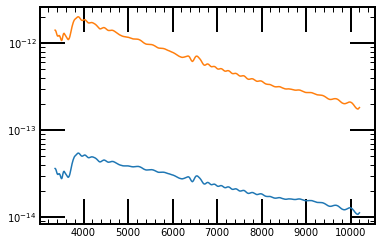

In [7]:
plt.plot(xpsamp.wavelength*10,xpsamp.flux*10)
plt.plot(xpsamp.wavelength*10,flux_intrinsic)
plt.yscale('log')


In [ ]:
"""
    temp = xpsamp
    temp['wavelength'] = temp['wavelength']/1000
    temp['flux'] = temp['flux']/10
    #A_V = 1.1


    alambda_av = ex.extinction(temp['wavelength'],A_V)
    #print (alambda_av)
    #print type(alambda_av)
    alambda = A_V*alambda_av
    opacity = alambda/1.086
    #print (opacity)

    flux_intrinsic = temp['flux']*np.exp(opacity)
    flux_intrinsic = flux_intrinsic*1000
"""

In [ ]:
import os
path_to_theo_spectra = "/home/arun/Desktop/SED/General_SED/SED_file/Shridhar/"
for spec_filename in os.listdir(path_to_theo_spectra):
    print(path_to_theo_spectra+spec_filename)
    A = SED_fit(path_to_theo_spectra+spec_filename)
    


In [55]:
df1 = xpsamp


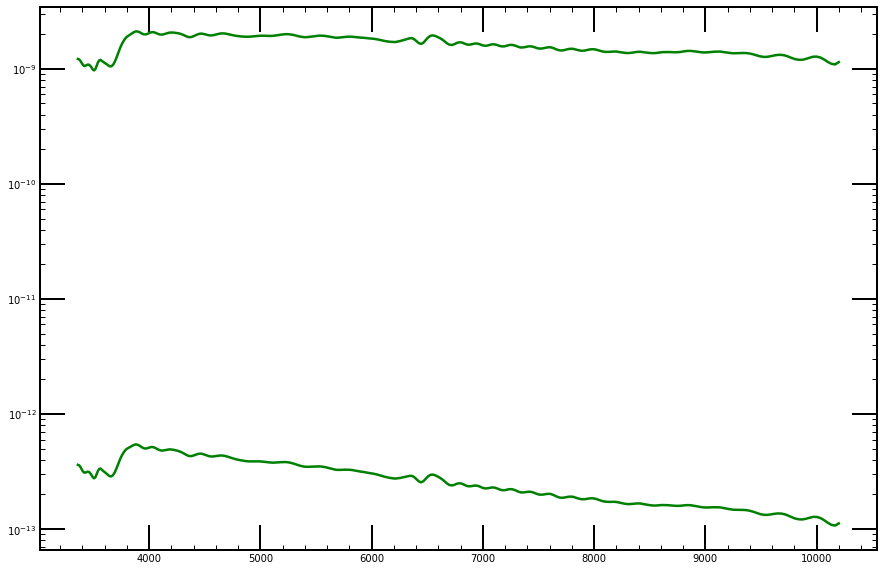

In [58]:
plt.plot(df1['wavelength']*10,df1['flux']*100,linewidth=2.5,color='g',label='BP/RP Spectra')
plt.plot(df1['wavelength']*10,df1['flux']*df1['wavelength']*1000,linewidth=2.5,color='g',label='BP/RP Spectra')

plt.yscale('log')


In [ ]:

#df1['flux'] = df1['flux']*df1['wavelength']*1000
plt.plot(df1['wavelength']*10,df1['flux']*df1['wavelength']*1000,linewidth=2.5,color='g',label='BP/RP Spectra')
plt.yscale('log')
df1['wavelength']

In [ ]:
star = "Gaia DR3 3346925145982116736"
av = 0
file_gen = sed_file_gen(star,av)


In [ ]:
A = sed_file_gen(star, av)

In [ ]:
from gaiaxpy import convert
import os, glob
import matplotlib.pyplot as plt
import pandas as pd
from gaiaxpy import generate, PhotometricSystem


data = pd.read_csv("/home/arun/Desktop/OBA_DR3/final_OBA_DR3_complilation-result_all_allgaia.csv", low_memory=False)
for xp in os.listdir("/home/arun/Desktop/OBA_DR3/xp_continuous_fits"):
    try:
        print(xp)
        dat = '/home/arun/Desktop/OBA_DR3/xp_continuous_fits/'+xp
        #phot_system = [PhotometricSystem.IPHAS, PhotometricSystem.SDSS]
        #synthetic_photometry = generate(dat, photometric_system=phot_system)
        dataa = data[data['DR3Name'] == str(xp.split('-')[-1].split('.')[0])]
        #synthetic_photometry1 = pd.merge(dataa, synthetic_photometry)    #print(cont_spec.split('-')[-1].split('.')[0], synthetic_photometry.Iphas_mag_Ha.values)
        #result = pd.concat([result,synthetic_photometry1], ignore_index=True)
        file_gen = sed_file_gen(dataa['DR3Name'].values[0], 0.)
        #converted_spectra, sampling = convert(dat)
        xpsamp = "/home/arun/Desktop/OBA_DR3/xp_sampled/XP_SAMPLED-"+dataa['DR3Name'].values[0]+'.csv'
        #A,B = SED_fit('./sed_files/SED_{}.csv'.format(dataa['DR3Name'].values[0]), xpsamp)
        #plt.scatter(xpsamp['wavelength'], xpsamp['flux'])
        plotter(file_gen,xpsamp,dataa['DR3Name'].values[0])
    except FileNotFoundError:
        print(xp, ' doesnot have sampled')

In [ ]:

synth_dic = {'Jkc_mag_U':'JsUmag','Jkc_mag_B':'JsBmag','Jkc_mag_V':'JsBmag','Jkc_mag_R':'JsRmag',
             'Jkc_mag_I':'JsImag','Sdss_mag_u':'umag','Sdss_mag_g':'gmag','Sdss_mag_r':'rmag',
             'Sdss_mag_i':'imag','Sdss_mag_z':'zmag','Panstarrs1_mag_gp':'gpsmag','Panstarrs1_mag_rp':'rpsmag',
             'Panstarrs1_mag_ip':'ipsmag','Panstarrs1_mag_zp':'zpsmag','Panstarrs1_mag_yp':'ypsmag',
             'GaiaDr3Vega_mag_G':'Gmag','GaiaDr3Vega_mag_BP':'BPmag','GaiaDr3Vega_mag_RP':'RPmag'}

result = pd.DataFrame([])
xp = 'XP_CONTINUOUS-Gaia DR3 3354703263034279808.fits'
dat = '/home/arun/Desktop/OBA_DR3/xp_continuous_fits/'+xp
phot_system = [PhotometricSystem.JKC,PhotometricSystem.SDSS,PhotometricSystem.PanSTARRS1,PhotometricSystem.Gaia_DR3_Vega]
synthetic_photometry = generate(dat, photometric_system=phot_system)
new_table = pd.DataFrame([])
a = "Gaia DR3 "+str(synthetic_photometry['source_id'].values[0])
new_table['Name'] = synthetic_photometry['source_id']
new_table['Name'] = "Gaia DR3 "+str(new_table['Name'].values[0])
new_table['Av'] = 0.
new_table['Dist'] = 0.
print(new_table)
for col in synthetic_photometry.columns:
    for bnd_nm in synth_dic:
        if col == bnd_nm:
            new_table[synth_dic[bnd_nm]] = synthetic_photometry[col].values[0]
            error = "e_"+synth_dic[bnd_nm]
            new_table[error]=0.1
            print(synthetic_photometry[col].values[0])
dataa = data[data['DR3Name'] == str(xp.split('-')[-1].split('.')[0])]
synthetic_photometry1 = pd.merge(dataa, synthetic_photometry)    #print(cont_spec.split('-')[-1].split('.')[0], synthetic_photometry.Iphas_mag_Ha.values)
result = pd.concat([result,synthetic_photometry1], ignore_index=True)
new_table = pd.DataFrame([])
a = "Gaia DR3 "+str(synthetic_photometry['source_id'].values[0])
new_table['Name'] = synthetic_photometry['source_id']
new_table['Name'] = "Gaia DR3 "+str(new_table['Name'].values[0])
new_table['Av'] = 0.
new_table['Dist'] = 0.
print(new_table)
for col in synthetic_photometry.columns:
    for bnd_nm in synth_dic:
        if col == bnd_nm:
            new_table[synth_dic[bnd_nm]] = synthetic_photometry[col].values[0]
            error = "e_"+synth_dic[bnd_nm]
            new_table[error]=0.1
            print(synthetic_photometry[col].values[0])
synth = "sample.csv"
new_table.to_csv(synth)

#file_gen = sed_file_gen(dataa['DR3Name'].values[0], 0.)
#converted_spectra, sampling = convert(dat)
xpsamp = "/home/arun/Desktop/OBA_DR3/xp_sampled/XP_SAMPLED-"+dataa['DR3Name'].values[0]+'.csv'
#A,B = SED_fit('./sed_files/SED_{}.csv'.format(dataa['DR3Name'].values[0]), xpsamp)
#plt.scatter(xpsamp['wavelength'], xpsamp['flux'])
fitter(flux_wavel_dict(synth),synth)
plotter(file_gen,synth,xpsamp,dataa['DR3Name'].values[0])

In [ ]:
synthetic_photometry.to_csv("save.csv")

In [ ]:
for i in range len(synthetic_photometry):
    

In [ ]:
new_table = pd.DataFrame([])
a = "Gaia DR3 "+str(synthetic_photometry['source_id'].values[0])
new_table['Name'] = synthetic_photometry['source_id']
new_table['Name'] = "Gaia DR3 "+str(new_table['Name'].values[0])
new_table['Av'] = 0.
new_table['Dist'] = 0.
print(new_table)
for col in synthetic_photometry.columns:
    for bnd_nm in synth_dic:
        if col == bnd_nm:
            new_table[synth_dic[bnd_nm]] = synthetic_photometry[col].values[0]
            error = "e_"+synth_dic[bnd_nm]
            new_table[error]=0.1
            print(synthetic_photometry[col].values[0])

In [ ]:
"e_"+synth_dic[bnd_nm]

In [ ]:
type(a)

In [ ]:
new_table

In [ ]:
plotter("sample.csv",xpsamp,dataa['DR3Name'].values[0])

In [ ]:
def flux_wavel_dict(phot_filename):
    import pandas as pd
    import timeit
    import numpy as np
    import copy
    import matplotlib.pyplot as plt
    import os
    import csv
    import matplotlib.backends.backend_pdf
    import astropy
    from astropy import units as u
    from astropy.coordinates import SkyCoord
    from astropy.table import Table
    from scipy import interpolate
    from scipy.interpolate import interp1d 
    from astropy.io import ascii
    dict_of_wavelength_info={'Gmag': [23, 5836.3, 2835.1, 0.93444], 'BPmag': [27, 5020.9, 3393.3, 1.12978], 'RPmag': [31, 7588.8, 2485.1, 0.66304], 'gpsmag': [18, 4775.6, 3909.1, 1.2013], 'rpsmag': [23, 6129.5, 3151.4, 0.88592], 'ipsmag': [28, 7484.6, 2584.6, 0.67699], 'zpsmag': [33, 8657.8, 2273.1, 0.51994], 'ypsmag': [38, 9613.5, 2203.0, 0.44049], 'Jmag': [20, 12350, 1594, 0.28726], 'Hmag': [23, 16620, 1024, 0.17256], 'Ksmag': [26, 21590, 666.7, 0.11157], 'IRAC1mag': [74, 35075.1, 280.9, 0.04913], 'IRAC2mag': [76, 44365.8, 179.7, 0.03504], 'IRAC3mag': [78, 56281.0, 115.0, 0.0265], 'IRAC4mag': [80, 75891.6, 64.9, 0.0265], 'W1mag': [0, 33526.0, 309.5, 0.05296], 'W2mag': [0, 46028.0, 171.8, 0.03252], 'W3mag': [0, 115608.0, 31.7, 0.0265], 'W4mag': [0, 220883.0, 8.4, 0.0265],'MIPSmag': [0, 238433.07, 7.07, 0.0265], 'JsBmag': [0, 4378.1, 4023.8, 1.31758], 'JsVmag': [0, 5466.1, 3562.5, 0.99997], 'JsRmag': [0, 6695.6, 2814.9, 0.79224], 'JsImag': [0, 8565.1, 2282.8, 0.53235], 'Rcmag': [0, 6358.0, 3028.0, 0.84811], 'Icmag': [0, 7829.2, 2458.3, 0.63086], 'umag': [0, 3594.9, 1568.5, 1.55723], 'gmag': [0, 4640.4, 3965.9, 1.24072], 'rmag': [0, 6122.3, 3162.0, 0.88711], 'imag': [0, 7439.5, 2602.0, 0.68303], 'zmag': [0, 8897.7, 2244.7, 0.48782], 'upmag': [0, 3542.2, 1469.5, 1.57151], 'gpmag': [0, 4724.6, 3921.0, 1.21617], 'rpmag': [0, 6202.6, 3112.9, 0.87382], 'ipmag': [0, 7673.0, 2502.6, 0.65177], 'zpmag': [0, 10506.5, 1821.0, 0.39009], 'gxfuvmag': [0, 1549.0, 520.7, 2.60956],'JsUmag': [0, 3570.6, 1564.2, 1.4258], 'gxnuvmag': [0, 2304.7, 788.5, 2.79148], 'VistaJmag': [0, 12481.0, 1550.7, 0.28276], 'VistaHmag': [0, 16348.2, 1027.3, 0.17979], 'VistaKmag': [0, 21435.5, 669.6, 0.11460],'N_Ksmag': [0, 21240.60, 677.43, 0.1170],'Lpmag': [0, 37301.72, 248.30, 0.04621],'IPHAS_Hamag':[0,6568.2,2609.8,0.81]}
    '''
    dict_of_wavelength_info={'Gmag': [23, 5836.3, 2835.1, 0.948], 'BPmag': [27, 5020.9, 3393.3, 1.08017], 'RPmag': [31, 7588.8, 2485.1, 0.71945], 'gpsmag': [18, 4775.6, 3909.1, 1.12435], 'rpsmag': [23, 6129.5, 3151.4, 0.908], 'ipsmag': [28, 7484.6, 2584.6, 0.7318], 'zpsmag': [33, 8657.8, 2273.1, 0.59272], 'ypsmag': [38, 9603.1, 2206.0, 0.51298], 'Jmag': [20, 12350, 1594, 0.33454], 'Hmag': [23, 16620, 1024, 0.20096], 'Ksmag': [26, 21590, 666.7, 0.12993], 'IRAC1mag': [74, 35075.1, 280.9, 0.05721], 'IRAC2mag': [76, 44365.8, 179.7, 0.04081], 'IRAC3mag': [78, 56281.0, 115.0, 0.03086], 'IRAC4mag': [80, 75891.6, 64.9, 0.03086], 'W1mag': [0, 33526.0, 309.5, 0.06168], 'W2mag': [0, 46028.0, 171.8, 0.03787], 'W3mag': [0, 115608.0, 31.7, 0.03086], 'W4mag': [0, 220883.0, 8.4, 0.03086], 'JsBmag': [0, 4378.1, 4023.8, 1.1958],'JsUmag': [0, 3570.6, 1564.2, 1.2858], 'JsVmag': [0, 5466.1, 3562.5, 0.99998], 'JsRmag': [0, 6695.6, 2814.9, 0.83078], 'JsImag': [0, 8565.1, 2282.8, 0.60371], 'Rcmag': [0, 6358.0, 3028.0, 0.87683], 'Icmag': [0, 7829.2, 2458.3, 0.69095], 'umag': [0, 3594.9, 1568.5, 1.32448], 'gmag': [0, 4640.4, 3965.9, 1.1487], 'rmag': [0, 6122.3, 3162.0, 0.90899], 'imag': [0, 7439.5, 2602.0, 0.73715], 'zmag': [0, 8897.7, 2244.7, 0.56428], 'upmag': [0, 3542.2, 1469.5, 1.32692], 'gpmag': [0, 4724.6, 3921.0, 1.13354], 'rpmag': [0, 6202.6, 3112.9, 0.89803], 'ipmag': [0, 7673.0, 2502.6, 0.70947], 'zpmag': [0, 10506.5, 1821.0, 0.45429], 'gxnuvmag': [0, 1549.0, 520.7, 1.48909], 'gxfuvmag': [0, 2304.7, 788.5, 1.79283]}

    '''


    Vega_mag_optbands=['Gmag','BPmag','RPmag','Icmag','Rcmag','JsVmag','JsBmag','JsUmag','JsRmag','JsImag','Jmag','Hmag','Ksmag','IRAC1mag','IRAC2mag','IRAC3mag','IRAC4mag','W1mag','MIPSmag','W2mag','W3mag','W4mag','VistaJmag','VistaHmag','VistaKmag','N_Ksmag','Lpmag','IPHAS_Hamag']
    AB_mag_optbands=['gpsmag', 'rpsmag', 'ipsmag', 'zpsmag', 'ypsmag','gpmag','rpmag','ipmag','gxnuvmag','gxfuvmag','umag','gmag','rmag','imag','zmag']#should add more optical bands respectively
    wv_info=copy.deepcopy(dict_of_wavelength_info)
    list_all_wavelengths_mstr=[p[1] for p in list(wv_info.values())] 
    zero_magnitude_flux_mstr=[p[2] for p in list(wv_info.values())]
    objct_flux_data=dict() 
    all_obj_wavelengths=dict()                          # Dictionary containing all the wavelength bands (wavelength values) that are available for the stars showing IR excess.
    all_objct_flux_data_list=dict()
    all_obj_extinction = dict()
    
    star_phot_data = pd.read_csv(phot_filename,na_values=['-','999','-999'])

    for index,row in star_phot_data.iterrows():
        AV = np.float(row['Av'])
        Star_name = row['Name']
        Distance_pc = np.float(row['Dist'])
    #print(index)    
    opt_bands=[]
    bands=[]
    lis_opt_wvls=[]## Only if the object has data in all 2MASS bands plus IRAC 1&2, is the object considered for furter analysis
        #print(row[['Jmag','Hmag','Ksmag','IRAC1mag','IRAC2mag']].notna())
    obj_bands=[]################################
    list_all_wavelengths=[]
    dict_obj_mags = dict()
    flux_wvlngth=dict()
    flx_err=dict()
    err_cnt=0
    dict_obj_mags_wo_corctn = dict()
    dict_obj_mags_err = dict()
    for bnd_nm in dict_of_wavelength_info:
        all_obj_extinction[bnd_nm] = dict_of_wavelength_info[bnd_nm][3]*AV
    for bnd_nm in dict_of_wavelength_info:
                if (bnd_nm in star_phot_data.columns) and (row[[bnd_nm]].notna().sum()) == 1:
                    opt_bands.append(bnd_nm)
                    dict_obj_mags[bnd_nm]=float(row[bnd_nm])-all_obj_extinction[bnd_nm]
                    dict_obj_mags_wo_corctn[bnd_nm]=float(row[bnd_nm])
                    dict_obj_mags_err[bnd_nm]=float(row['e_'+bnd_nm])
                    lis_opt_wvls.append(wv_info[bnd_nm][1])
    bands=opt_bands+bands
    list_all_wavelengths=lis_opt_wvls+list_all_wavelengths
    list_opt_flx=[]
    list_opt_flx_err=[]
    for bnd_nm in opt_bands:
        if bnd_nm in Vega_mag_optbands:
            #print('sdfgds')
            mag_wvlngth=dict_obj_mags[bnd_nm]
            flux_wvlngth[bnd_nm]=(2.99792458e-05*(wv_info[bnd_nm][2]*10**(-mag_wvlngth/2.5)))/(wv_info[bnd_nm][1]**2)# Converting magnitude to flux in Jansky -> Converting Janksy to erg/cm2/s/A (formula from "http://www.stsci.edu/~strolger/docs/UNITS.txt") -> Finally multiplying with wvelength to get lambda*F_lambda in erg/cm2/s.
            list_opt_flx.append(flux_wvlngth[bnd_nm])
            mg_err=mag_wvlngth+float(row['e_'+bnd_nm])
            if float(row['e_'+bnd_nm])>90:
                mg_err=mag_wvlngth
            err_corctd_flx=(2.99792458e-05*(wv_info[bnd_nm][2]*10**(-mg_err/2.5)))/(wv_info[bnd_nm][1]**2)
            flx_err[bnd_nm]=flux_wvlngth[bnd_nm]-err_corctd_flx
            list_opt_flx_err.append(flx_err[bnd_nm])
        if bnd_nm in AB_mag_optbands:
            mag_wvlngth=dict_obj_mags[bnd_nm]
            flux_wvlngth[bnd_nm]=(2.99792458e-05*(3631*10**(-mag_wvlngth/2.5)))/(wv_info[bnd_nm][1]**2)           # Converting magnitude to flux in Jansky -> Converting Janksy to erg/cm2/s/A (formula from "http://www.stsci.edu/~strolger/docs/UNITS.txt") -> Finally multiplying with wvelength to get lambda*F_lambda in erg/cm2/s.
            list_opt_flx.append(flux_wvlngth[bnd_nm])
            mg_err=mag_wvlngth+float(row['e_'+bnd_nm])
            if float(row['e_'+bnd_nm])>90:
                mg_err=mag_wvlngth
            err_corctd_flx=(2.99792458e-05*(3631*10**(-mg_err/2.5)))/(wv_info[bnd_nm][1]**2)
            flx_err[bnd_nm]=flux_wvlngth[bnd_nm]-err_corctd_flx
            list_opt_flx_err.append(flx_err[bnd_nm])
                                                    
        objct_flux_data[index]=flux_wvlngth
        obj_nor_band_flux=objct_flux_data[index][opt_bands[0]]
    #print(flux_wvlngth,flx_err)
    a=[]
    b=[]
    for bnd_nm in bands:
        a.append(flux_wvlngth[bnd_nm])
        b.append(dict_of_wavelength_info[bnd_nm][1])
    final_dic = dict()
    final_dic1 = dict()
    final_dic2 = dict()
    for bnd_nm in flux_wvlngth:
        final_dic[bnd_nm]=flux_wvlngth[bnd_nm]
        final_dic1[bnd_nm] = dict_of_wavelength_info[bnd_nm][1]
        final_dic2[bnd_nm] = flx_err[bnd_nm]

    from itertools import chain
    from collections import defaultdict
    FINAL_DIC = defaultdict(list)
    for d in (final_dic1, final_dic, final_dic2): # you can list as many input dicts as you want here
        for key, value in d.items():
            FINAL_DIC[key].append(value)
    FINAL_DIC = dict(sorted(FINAL_DIC.items(), key=lambda k_v: k_v[1][0]))
    return(FINAL_DIC)

def near(A,value):
    import numpy as np
    idx = (np.abs(A-value)).argmin()
    return (idx)

def fitter(FINAL_DIC,phot_filename):
    import pandas as pd
    import timeit
    import numpy as np
    import copy
    import matplotlib.pyplot as plt
    import os
    import csv
    import matplotlib.backends.backend_pdf
    import astropy
    from astropy import units as u
    from astropy.coordinates import SkyCoord
    from astropy.table import Table
    from scipy import interpolate
    from scipy.interpolate import interp1d 
    from astropy.io import ascii
    x = []
    y = []
    z = []
    star_phot_data = pd.read_csv(phot_filename,na_values=['-','999','-999'])
    for index,row in star_phot_data.iterrows():
        AV = np.float(row['Av'])
        Star_name = row['Name']
        Distance_pc = np.float(row['Dist'])
    for i in FINAL_DIC:
        #print(A[i][0])
        #a = A[i][1]
        x.append(FINAL_DIC[i][0])
        y.append(FINAL_DIC[i][1])
        z.append(FINAL_DIC[i][2])
    sed_fitting_bands = []
    for bnd_nm in FINAL_DIC:
        sed_fitting_bands.append(bnd_nm)
    print(sed_fitting_bands)

    filename_count = 0
    Temp_filename_dict = dict()
    least_sq_theo_sed=dict()

    path_to_theo_phot = "/home/arun/Desktop/SED/General_SED/LOG_4_5/bt-nextgen-agss2009_phot_1647494142.2956"
    for filename in os.listdir(path_to_theo_phot):
        filename_count+=1 
        indv_wvl_lambda_Flambda=dict()
        Temp_filename_dict[filename_count]=filename
        data = ascii.read(path_to_theo_phot+"/"+filename)
        A_wave = data.columns[1]
        B_flux = data.columns[2]
        Band_norm = 'Gmag'
        wavel_n1 = FINAL_DIC[Band_norm][0]
        flux_n1 = FINAL_DIC[Band_norm][1]
        index_fit = near(A_wave,wavel_n1)
        norm_phot_flux = (B_flux/B_flux[index_fit])*flux_n1
        least_sq = []
        for chi_bnd in sed_fitting_bands:
            index_fit = near(A_wave,FINAL_DIC[chi_bnd][0])
            nor_temp_band_lambda_Flambda = norm_phot_flux[index_fit]
            obj_lambda_Flambda=FINAL_DIC[chi_bnd][1]# Object lambda_Flambda at that wavelength.
            obj_flx_err=FINAL_DIC[chi_bnd][2]# observed flux error in that band
            if obj_flx_err==0: # If there is not error then a high error value of 1 is taken.
                obj_flx_err=1
            x2=((obj_lambda_Flambda-nor_temp_band_lambda_Flambda)**2/nor_temp_band_lambda_Flambda)                                                         # Chi-squared or least sqaured formula using the theoretical and observed lambda_Flambda.
            eff_temp_1=float(filename[23:26])*100# The effective temperature of the best fit spectra
            sur_g_1=float(filename[27:30])
            least_sq.append(x2)

            total_x2=(1/(len(sed_fitting_bands)-1))*sum(least_sq)

        least_sq_theo_sed[filename]=sum(least_sq)
        #print(eff_temp_1,sur_g_1,sum(least_sq))
    #print(least_sq_theo_sed)
    spec_phot_filename=min(least_sq_theo_sed, key=least_sq_theo_sed.get)
    #print(spec_phot_filename)
    eff_temp=float(spec_phot_filename[23:26])*100# The effective temperature of the best fit spectra
    sur_g=float(spec_phot_filename[27:30])
    #print(eff_temp,sur_g)

    path_to_theo_spectra = "/home/arun/Desktop/SED/General_SED/LOG_4_5/bt-nextgen-agss2009"

    for spec_filename in os.listdir(path_to_theo_spectra):
        if spec_filename[3:6] == spec_phot_filename[23:26] and spec_filename[7:10] == spec_phot_filename[27:30]:
            spectra_fit_filename=spec_filename
    data_spectra_fit_filename = ascii.read(path_to_theo_spectra+"/"+spectra_fit_filename)
#print(spectra_fit_filename)
    data_PHOT = ascii.read(path_to_theo_phot+"/"+spec_phot_filename)

    Spec_wave = data_spectra_fit_filename.columns[0]
    Spec_flux = data_spectra_fit_filename.columns[1]
    Spec_index_fit = near(Spec_wave,wavel_n1)
    norm_spec_flux = (Spec_flux/Spec_flux[Spec_index_fit])*flux_n1
    A_wave = data_PHOT.columns[1]
    B_flux = data_PHOT.columns[2]
    index_fit = near(A_wave,wavel_n1)
    Md = flux_n1/B_flux[index_fit]
    norm_phot_flux = (B_flux*Md)
    #Radius = np.sqrt(Md*Distance_pc**2)*4.435e+7
    print("Star_name = ",Star_name,"Teff = ",eff_temp,"log g = ",sur_g)#,"Radius = ",Radius)
    #result = [Star_name,eff_temp,sur_g,Radius]
    wvx = []
    wvy = []
    for ss in FINAL_DIC:
        ind = near(A_wave,FINAL_DIC[ss][0])
        wvx.append(A_wave[ind])
        wvy.append(norm_phot_flux[ind])
    #plt.errorbar(x,y,yerr=z,marker='o',ms=10, mfc='red',ls='none',label='%s'%Star_name)
    #plt.scatter(wvx,wvy,color='b',s=40,label='Model_photometry')
    #plt.plot(Spec_wave,norm_spec_flux,'k-',linewidth=1,alpha=0.4,label='BT-NextGen(AGSS2009)\nTeff = %s K, log g = %s'%(str(eff_temp)[:-2],sur_g))
    #plt.legend(loc='best',prop={'size': 10,'weight':'bold'}, ncol=1)
    #plt.xscale('log')
    #plt.yscale('log')
    #plt.xlabel('Wavelength ($\AA$)',fontsize=18,fontweight='bold')
    #plt.ylabel('$F_\lambda$ $(erg/cm^2 /s/\AA)$',fontsize=18,fontweight='bold')
    #plt.xlim(min(x)-500,max(x)+5000)
    #plt.ylim(min(wvy)-(min(wvy)/0.21e1),max(wvy)+(max(wvy)/0.21e1))
    #params = {'mathtext.default': 'regular' }          
    #plt.rcParams.update(params)
    #plt.tick_params(direction='in', which ="major",labelsize = 15,length=8, width=2,colors='k',grid_color='k', grid_alpha=1,bottom=True, top=True, left=True, right=True)
    #plt.xticks(weight = 'bold')
    #plt.yticks(weight = 'bold')
    #plt.legend(prop={'size': 12,'weight':'bold'}, ncol=1)
    #fig =plt.gcf()
    #fig.set_size_inches(13.5, 8.5)
    return(Spec_wave,norm_spec_flux,str(eff_temp)[:-2],sur_g)


In [ ]:
fitter(flux_wavel_dict(synth),synth)

In [ ]:
type(data)

In [ ]:
if type(data) == pd.core.frame.DataFrame:
    print(True)
    

In [33]:
def sed_file_gen(Name, Av):
    from astroquery.vizier import Vizier
    from astroquery.mast import Catalogs
    import astropy.units as units
    import matplotlib.pyplot as plt
    import astropy.units as u
    import astropy.coordinates as coord
    import os
    import csv
    import numpy as np
    v = Vizier(columns=["*", "+_r"])
    Phot_Name = []
    Gaia_dat = ['Name','RA','DEC','Av','Dist','Gmag','e_Gmag','BPmag','e_BPmag','RPmag','e_RPmag']
    TWOMASS_dat = ['Jmag','e_Jmag','Hmag','e_Hmag','Ksmag','e_Ksmag']
    WISE_dat = ['W1mag','e_W1mag','W2mag','e_W2mag','W3mag','e_W3mag','W4mag','e_W4mag']
    SDSS_dat = ['umag','e_umag','gmag','e_gmag','rmag','e_rmag','imag','e_imag','zmag','e_zmag']
    PAN_dat = ['gpsmag','e_gpsmag','rpsmag','e_rpsmag','ipsmag','e_ipsmag','zpsmag','e_zpsmag','ypsmag','e_ypsmag']
    B_V_dat = ['JsBmag','e_JsBmag','JsVmag','e_JsVmag']
    Galex_dat = ['gxfuvmag','e_gxfuvmag','gxnuvmag','e_gxnuvmag']
    Phot = []
    try:#
        Gaia = v.query_region(Name, radius="5s",catalog="I/345/gaia2")
        Star_ID = Gaia[0][0]['Source']
        Bailer = v.query_region('Gaia DR2 '+str(Star_ID), radius="2s",catalog="I/347/gaia2dis")
        print(len(Gaia[0]))
        Phot_Name.append(Gaia_dat)
        Phot_Name = np.reshape(Phot_Name, (11))
        A = [Name,Gaia[0][0]['RA_ICRS'],Gaia[0][0]['DE_ICRS'],Av,Bailer[0][0]['rest'],Gaia[0][0]['Gmag'],
             Gaia[0][0]['e_Gmag'],Gaia[0][0]['BPmag'],Gaia[0][0]['e_BPmag'],Gaia[0][0]['RPmag'],
             Gaia[0][0]['e_RPmag']]
        Phot.append(A)
        A = np.reshape(A, (11))
    except:
        IndexError
    
    try:#
        sdss = v.query_region(Name, radius="5s",catalog="V/147/sdss12")
        print(len(sdss[0]))
        Phot_Name = np.append(Phot_Name,SDSS_dat)
        D = [sdss[0][0]['umag'],sdss[0][0]['e_umag'],sdss[0][0]['gmag'],sdss[0][0]['e_gmag'],
             sdss[0][0]['rmag'],sdss[0][0]['e_rmag'],sdss[0][0]['imag'],sdss[0][0]['e_imag'],
             sdss[0][0]['zmag'],sdss[0][0]['e_zmag']]
        Phot = np.append(Phot,D)
    except:
        IndexError
    try:#
        print("trying pan")
        pan = v.query_region(Name, radius="5s",catalog="II/349/ps1")
        print(len(pan[0]))
        Phot_Name = np.append(Phot_Name,PAN_dat)

        D = [pan[0][0]['gmag'],pan[0][0]['e_gmag'],pan[0][0]['rmag'],pan[0][0]['e_rmag'],
             pan[0][0]['imag'],pan[0][0]['e_imag'],pan[0][0]['zmag'],pan[0][0]['e_zmag'],
             pan[0][0]['ymag'],pan[0][0]['e_ymag']]        
        Phot = np.append(Phot,D)
    except:
        IndexError
        print("Avoiding pan")
    try:
        UCAC = v.query_region(Name, radius="5s", catalog='I/322A/out')
        print(len(UCAC[0]))
        Phot_Name = np.append(Phot_Name,B_V_dat)
        E = [UCAC[0][0]['Bmag'],0.1,UCAC[0][0]['Vmag'],0.1]
        Phot = np.append(Phot,E)    
    except:
        IndexError
    print(Phot[0])
    dat = pd.DataFrame.from_records([Phot][0], columns = Phot_Name)
    print(dat)
    file_name = "/home/arun/Desktop/SED/General_SED/SED_file/SED_%s.csv"%Name
    with open(file_name, 'a') as writeFile1:
        writer = csv.writer(writeFile1)
        np.savetxt(writeFile1,[Phot_Name], delimiter=',', fmt='%s')
        np.savetxt(writeFile1,[Phot][0], delimiter=',', fmt='%s')
        writeFile1.close()
    return(file_name)

In [34]:
sed_file_gen("IL Cep", 3.)

1
trying pan
Avoiding pan
['IL Cep', 343.3150111336, 62.14582472121, 3.0, 789.581280879234, 8.995, 0.0003, 9.4765, 0.0013, 8.3654, 0.0019]
     Name          RA        DEC   Av        Dist   Gmag  e_Gmag   BPmag  \
0  IL Cep  343.315011  62.145825  3.0  789.581281  8.995  0.0003  9.4765   

   e_BPmag   RPmag  e_RPmag  
0   0.0013  8.3654   0.0019  


'/home/arun/Desktop/SED/General_SED/SED_file/SED_IL Cep.csv'